# Explore a paired RNA-seq experiment

Inspect 63,677 genes across eight airway samples; normalize depth, distinguish donor from treatment, and inspect paired responses.

**Bioinformatics · Lesson 03 · 60 minutes · Embedded real data · Offline core analysis**

## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the biological question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
RECIPE_ID='03-airway-expression'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'airway': '5440d5e8dc3a3da15735ad2592cf908bcfc7f4bdadc89b1404aa48d728bdeaab'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['airway']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def validate_counts(counts, metadata):
    if not counts.index.is_unique or not counts.columns.is_unique:
        raise ValueError("Gene and sample identifiers must be unique")
    if not metadata.index.is_unique or list(counts.columns) != list(metadata.index):
        raise ValueError("Sample columns must match metadata order exactly")
    values = counts.to_numpy()
    if not np.isfinite(values).all() or (values < 0).any() or not np.equal(values,np.floor(values)).all():
        raise ValueError("Counts must be finite nonnegative integers")
    if (values.sum(axis=0) == 0).any():
        raise ValueError("A sample has no reads")
    if set(metadata.condition) != {"control","treated"}:
        raise ValueError("Expected control and treated conditions")
    for donor, rows in metadata.groupby("donor", sort=True):
        if len(rows) != 2 or set(rows.condition) != {"control","treated"}:
            raise ValueError("Each donor needs one control and one treated sample: " + str(donor))

print("Method ready: validate_counts")


Method ready: validate_counts


In [4]:
def normalize_counts(counts, min_count=10, min_samples=4):
    values = counts.to_numpy(dtype=float)
    keep = (values >= min_count).sum(axis=1) >= min_samples
    filtered = counts.loc[keep].astype(float)
    positive = (filtered.to_numpy() > 0).all(axis=1)
    if positive.sum() == 0:
        raise ValueError("Median-ratio method needs genes positive in every sample")
    reference_values = filtered.to_numpy()[positive]
    geometric_means = np.exp(np.log(reference_values).mean(axis=1))
    factors = np.median(reference_values / geometric_means[:,None], axis=0)
    if not np.isfinite(factors).all() or (factors <= 0).any():
        raise ValueError("Invalid size factors")
    factors /= np.exp(np.log(factors).mean())
    normalized = filtered / factors
    return filtered, pd.Series(factors,index=counts.columns,name="size_factor"), normalized

print("Method ready: normalize_counts")


Method ready: normalize_counts


In [5]:
def paired_response(log_counts, metadata, min_effect=1.0, min_consistent=3):
    differences = {}
    for donor, rows in metadata.groupby("donor",sort=True):
        control = rows.index[rows.condition == "control"][0]
        treated = rows.index[rows.condition == "treated"][0]
        differences[donor] = log_counts[treated] - log_counts[control]
    differences = pd.DataFrame(differences)
    response = pd.DataFrame(dict(mean_log2_change=differences.mean(axis=1),
                                 positive_pairs=(differences>0).sum(axis=1),
                                 negative_pairs=(differences<0).sum(axis=1)))
    response["direction"] = "other"
    response.loc[(response.mean_log2_change>=min_effect)&(response.positive_pairs>=min_consistent),"direction"]="up"
    response.loc[(response.mean_log2_change<=-min_effect)&(response.negative_pairs>=min_consistent),"direction"]="down"
    return differences, response

print("Method ready: paired_response")


Method ready: paired_response


## Steps

### 1. Audit the experimental design

Four primary human airway smooth-muscle cell lines were measured under control and dexamethasone conditions. The **biological unit is the donor**, and the eight columns are not eight independent donors. The snapshot retains all 63,677 rows of the official airway count object. Sample labels must be matched by identifier, not sorted independently or inferred from column order.

In [6]:
airway = snapshot("airway")
counts = pd.DataFrame(airway["counts"], index=airway["genes"], columns=airway["samples"])
metadata = pd.DataFrame(airway["metadata"]).set_index("sample").loc[counts.columns]
validate_counts(counts, metadata)
print("Complete count matrix:", counts.shape)
def display_scroll_table(frame):
    # Keep identifiers and numeric values intact on narrow device screens.
    table = frame.to_html(border=0, classes="vibeit-scroll-table")
    style = """<style>
    table.vibeit-scroll-table {table-layout:auto !important;width:max-content !important;max-width:none !important;}
    table.vibeit-scroll-table th, table.vibeit-scroll-table td {
      white-space:nowrap !important;word-break:normal !important;padding:6px 8px;}
    </style>"""
    display(HTML(style+'<div style="max-width:100%;overflow-x:auto;-webkit-overflow-scrolling:touch">'+table+'</div>'))
display_scroll_table(metadata)
display_scroll_table(counts.iloc[:6])


Complete count matrix: (63677, 8)


,condition,donor,geo
SRR1039508,control,N61311,GSM1275862
SRR1039509,treated,N61311,GSM1275863
SRR1039512,control,N052611,GSM1275866
SRR1039513,treated,N052611,GSM1275867
SRR1039516,control,N080611,GSM1275870
SRR1039517,treated,N080611,GSM1275871
SRR1039520,control,N061011,GSM1275874
SRR1039521,treated,N061011,GSM1275875


,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ENSG00000000003,679,448,873,408,1138,1047,770,572
ENSG00000000005,0,0,0,0,0,0,0,0
ENSG00000000419,467,515,621,365,587,799,417,508
ENSG00000000457,260,211,263,164,245,331,233,229
ENSG00000000460,60,55,40,35,78,63,76,60
ENSG00000000938,0,0,2,0,1,0,0,0


### 2. Inspect library sizes before normalization

Total mapped gene counts describe how many reads were assigned to this count matrix. They are not the total sequencing yield or a complete quality report. Large depth differences can dominate raw-count comparisons. Here every library has reads; a zero-total library is rejected rather than divided by zero.

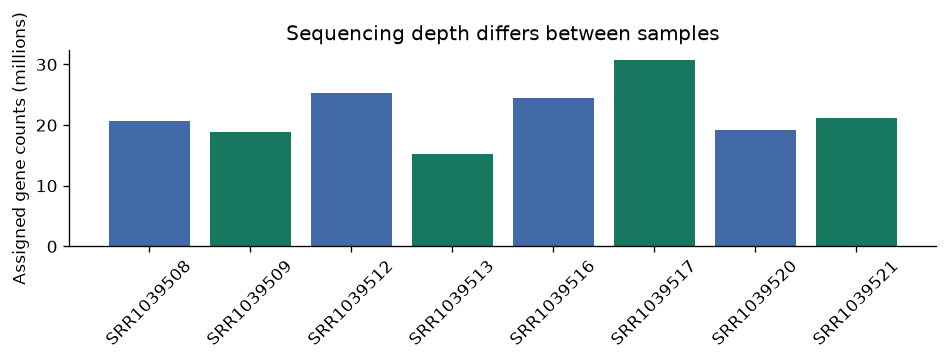

Original library totals verified


In [7]:
library_sizes=counts.sum(axis=0)
fig,ax=plt.subplots(figsize=(8,3))
ax.bar(range(len(counts.columns)),library_sizes/1e6,color=["#416aa6" if c=="control" else "#18785f" for c in metadata.condition])
ax.set(xticks=range(8),xticklabels=counts.columns, ylabel="Assigned gene counts (millions)",title="Sequencing depth differs between samples")
ax.tick_params(axis="x",rotation=45);plt.tight_layout();plt.show()
assert library_sizes.astype(int).tolist()==airway["library_totals"]
print("Original library totals verified")


### 3. Filter and estimate median-ratio size factors

Keep genes with at least 10 counts in at least four samples. For genes positive in every sample, calculate the geometric mean across samples, divide each count by that reference, and take the per-sample median. Rescale factors to geometric mean one. The method assumes most genes do not undergo a large shared directional change. This depth adjustment is not TPM and does not correct gene length.

In [8]:
MIN_COUNT, MIN_SAMPLES = 10, 4
filtered, size_factors, normalized = normalize_counts(counts, MIN_COUNT, MIN_SAMPLES)
log_counts = np.log2(normalized + 1)
print("Retained genes:", len(filtered), "of", len(counts))
print("Genes positive in every sample:", int((filtered > 0).all(axis=1).sum()))
display(size_factors.to_frame())


Retained genes: 16139 of 63677
Genes positive in every sample: 16072


,size_factor
SRR1039508,1.019000
SRR1039509,0.893462
SRR1039512,1.170560
SRR1039513,0.666422
SRR1039516,1.171945
SRR1039517,1.395186
SRR1039520,0.913847
SRR1039521,0.942312


### 4. Measure similarity after a transparent log transform

We use `log2(normalized counts + 1)` for teaching-scale exploration. It is **not DESeq2 VST or rlog**. Correlation uses the same retained genes for every sample pair. Closely related samples may share donor biology as well as treatment. Do not call a sample an outlier from this picture alone; check metadata and upstream quality evidence.

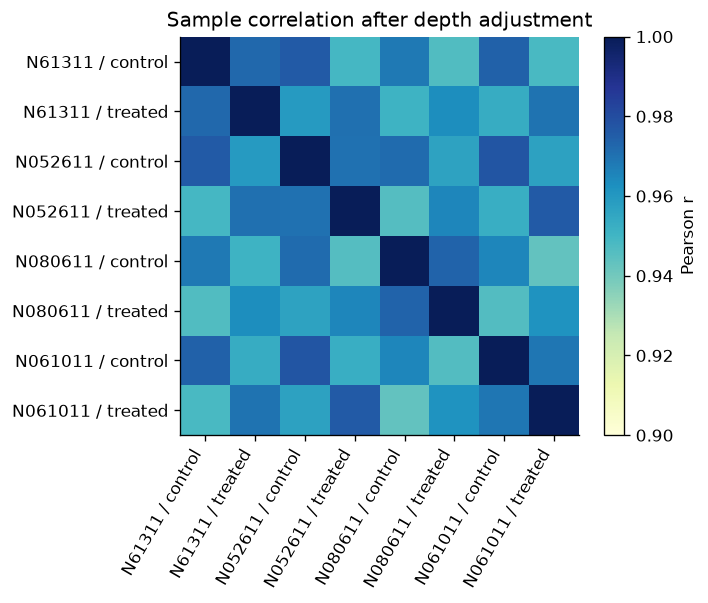

In [9]:
correlation=log_counts.corr()
fig,ax=plt.subplots(figsize=(6,5))
im=ax.imshow(correlation,vmin=.9,vmax=1,cmap="YlGnBu")
labels=[f"{r.donor} / {r.condition}" for r in metadata.itertuples()]
ax.set(xticks=range(8),yticks=range(8),xticklabels=labels,yticklabels=labels,title="Sample correlation after depth adjustment")
plt.setp(ax.get_xticklabels(),rotation=60,ha="right")
fig.colorbar(im,ax=ax,label="Pearson r");plt.tight_layout();plt.show()


### 5. Separate donor and treatment in PCA

Select at most 2,000 high-variance genes, transpose to samples × genes, and center each gene before SVD. No gene-wise unit-variance scaling is applied. Color indicates treatment; the connecting lines identify a donor pair. PCA signs may flip across numerical libraries without changing the geometry. PCA does not prove that treatment caused every visible axis.

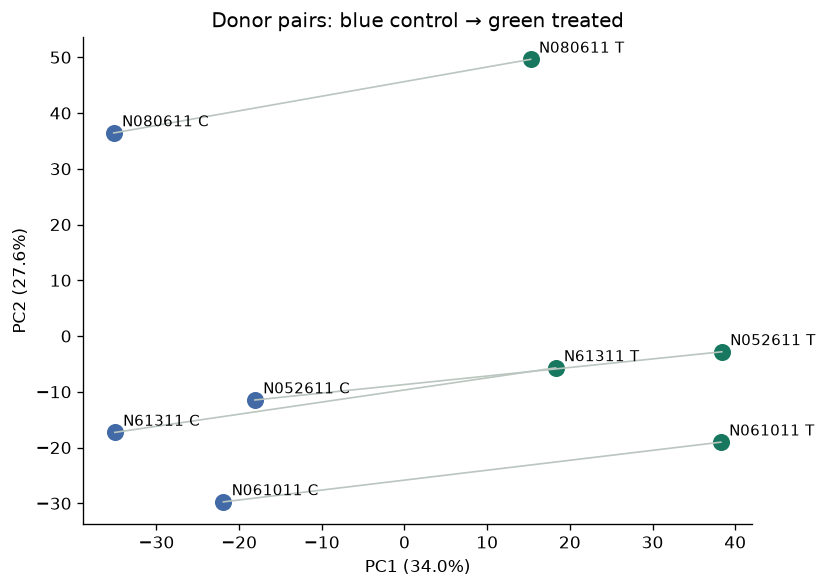

PCA uses 2000 genes; explained variance: [0.3400221 0.276398 ]


In [10]:
variable_genes=log_counts.var(axis=1).nlargest(min(2000,len(log_counts))).index
matrix=log_counts.loc[variable_genes].T.to_numpy()
matrix=matrix-matrix.mean(axis=0)
u,s,vt=np.linalg.svd(matrix,full_matrices=False)
coordinates=u[:,:2]*s[:2];explained=s**2/np.sum(s**2)
fig,ax=plt.subplots(figsize=(7,5))
for donor,rows in metadata.groupby("donor"):
    indices=[metadata.index.get_loc(sample) for sample in rows.index]
    ax.plot(coordinates[indices,0],coordinates[indices,1],color="#bac6bf",lw=1)
for i,row in enumerate(metadata.itertuples()):
    ax.scatter(*coordinates[i],s=85,color="#416aa6" if row.condition=="control" else "#18785f")
    ax.annotate(row.donor+(" C" if row.condition=="control" else " T"),coordinates[i],xytext=(5,4),textcoords="offset points",fontsize=9)
ax.set(xlabel=f"PC1 ({explained[0]:.1%})",ylabel=f"PC2 ({explained[1]:.1%})",title="Donor pairs: blue control → green treated")
plt.tight_layout();plt.show()
print("PCA uses",len(variable_genes),"genes; explained variance:",explained[:2])


### 6. Inspect paired effects, without assigning DEG p-values

Subtract each donor's control log-counts from its treated log-counts. The mean of four differences measures a descriptive treatment-associated change. Because we added one before taking logs, this is not a fitted negative-binomial log fold change. Select response candidates using effect size and direction consistency; formal differential expression requires a suitable count model with donor in its design.

,genes
direction,
other,15083
down,529
up,527


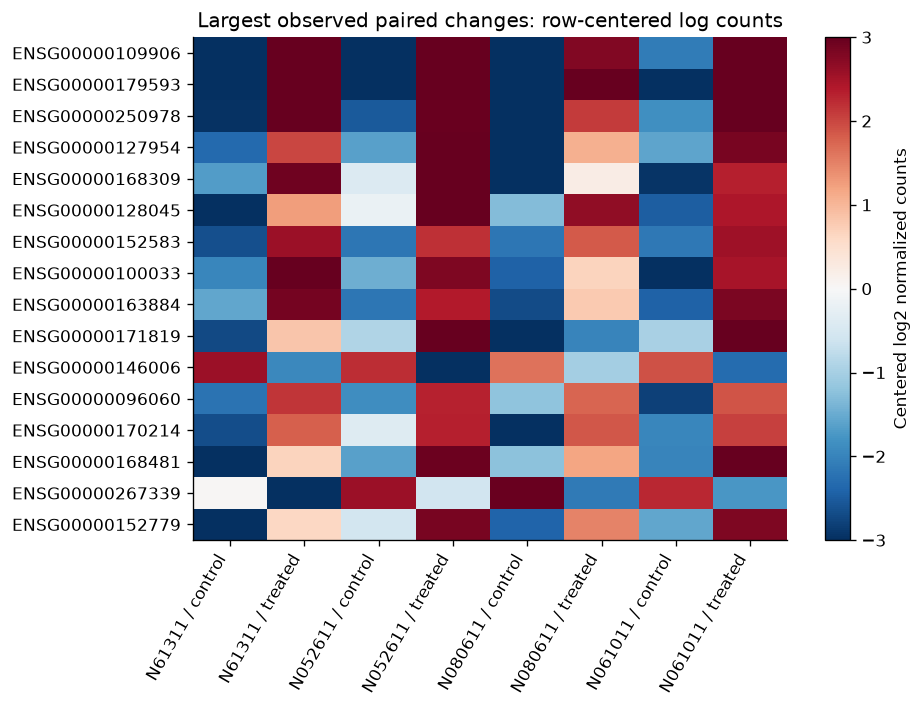

In [11]:
paired_changes,response=paired_response(log_counts,metadata,min_effect=1,min_consistent=3)
display(response.direction.value_counts().rename("genes").to_frame())
top=response.mean_log2_change.abs().nlargest(16).index
heat=log_counts.loc[top];heat=heat.sub(heat.mean(axis=1),axis=0)
fig,ax=plt.subplots(figsize=(8,6))
im=ax.imshow(heat,aspect="auto",cmap="RdBu_r",vmin=-3,vmax=3)
ax.set(xticks=range(8),xticklabels=labels,yticks=range(len(top)),yticklabels=top,
       title="Largest observed paired changes: row-centered log counts")
plt.setp(ax.get_xticklabels(),rotation=60,ha="right");fig.colorbar(im,ax=ax,label="Centered log2 normalized counts")
plt.tight_layout();plt.show()


### 7. Follow one measured gene across all donors

The original airway experiment investigated CRISPLD2 (ENSG00000103196). Check that the gene is in the measured, filtered matrix before plotting. The line endpoints represent normalized counts, not protein abundance. All four donors stay visible; showing only their average would hide heterogeneity.

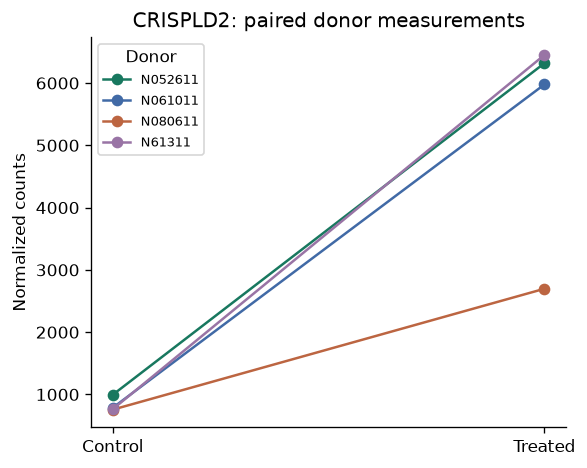

In [12]:
GENE="ENSG00000103196"
assert GENE in normalized.index
fig,ax=plt.subplots(figsize=(5,4))
for donor,rows in metadata.groupby("donor"):
    ordered=rows.set_index("condition").loc[["control","treated"],:]
    values=[normalized.loc[GENE,rows.index[rows.condition==condition][0]] for condition in ["control","treated"]]
    ax.plot([0,1],values,marker="o",label=donor)
ax.set(xticks=[0,1],xticklabels=["Control","Treated"],ylabel="Normalized counts",title="CRISPLD2: paired donor measurements")
ax.legend(title="Donor",fontsize=8);plt.tight_layout();plt.show()


### 8. Check and export the audit trail

Keep full results in files while showing small tables in the notebook. Counts remain integers before normalization; factors are positive; PCA explained fractions sum to one. The response table records its screening rule and includes every retained gene, including those that were not candidates.

In [13]:
assert np.isclose(np.exp(np.log(size_factors).mean()),1)
assert np.isclose(explained.sum(),1)
assert np.isfinite(log_counts.to_numpy()).all()
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
metadata.to_csv(OUTPUT_DIR/"samples.csv")
size_factors.to_csv(OUTPUT_DIR/"size-factors.csv")
response.to_csv(OUTPUT_DIR/"response-candidates.csv")
paired_changes.to_csv(OUTPUT_DIR/"paired-log2-changes.csv")
pd.DataFrame(coordinates,index=metadata.index,columns=["PC1","PC2"]).to_csv(OUTPUT_DIR/"pca.csv")
print("Checks passed. No differential-expression p-values were estimated.")


Checks passed. No differential-expression p-values were estimated.


## Exercises and reference explanation

1. Why should each donor have exactly one control and one treated sample?
2. Compare PCA colors by donor instead of condition. Keep the same matrix and coordinates.

**Reference explanation.** Pairing removes a donor's baseline from the descriptive difference. Relabeling colors does not alter PCA coordinates. A condition-only analysis can confound donor differences with treatment.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Add a PCA legend that separately encodes donor with marker shape and condition with color, using only NumPy, Pandas and Matplotlib. Keep the exact input matrix and explain variance unchanged.

**Prompt 2**

> Add a filter-sensitivity table for minimum counts 5, 10 and 20, retaining the four-sample requirement. Recalculate size factors each time and report candidate counts without assigning DEG p-values.

**Human acceptance.** Verify eight correctly ordered samples, four complete pairs, positive factors, unchanged source library totals and finite transformed values. Reordered metadata must raise an error.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [14]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://raw.githubusercontent.com/bioconductor-source/airway/596678815f4ade04a9711997150949b9782aeddc/DESCRIPTION',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [airway read counts](https://raw.githubusercontent.com/bioconductor-source/airway/596678815f4ade04a9711997150949b9782aeddc/data/airway.RData) — LGPL (airway package); original experiment: Himes et al. 2014; retrieved 2026-10-09. SHA-256 `98d05e82867ae4bed92295eb8863ab6c1aa694876f2b29b455c30a559f801cd0`.
  rdata 1.1.0: assays.data.listData['counts'], rowRanges.partitioning.NAMES, colData; no scaling or gene subsetting


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.